In [32]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from src.graphs.utils import *
from src.hyperbolicity.gromov import *
from src.graphs.visualization import *
from collections import Counter
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


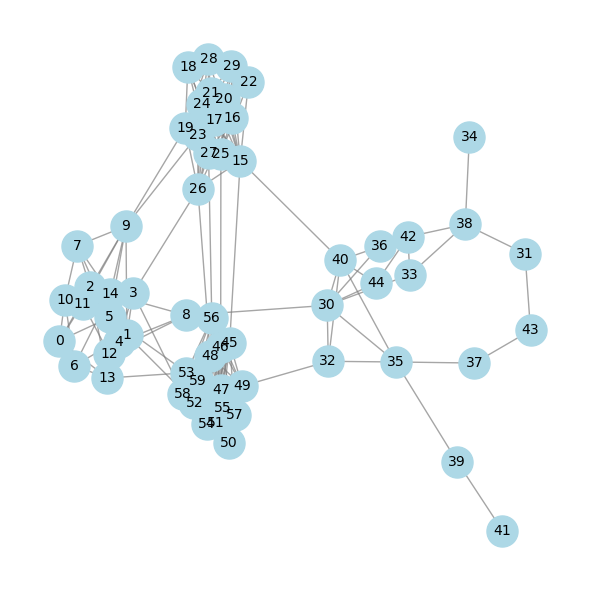

(<Figure size 600x600 with 1 Axes>, [<Axes: >])

In [34]:
sizes=[15,15,15,15]
p_intra=[0.4,0.6,0.2,0.8]
G = create_SBM_graph(sizes,p_intra)
pos = draw_layout(G)
draw_graphs(G,pos)

In [35]:
delta_max, quads = compute_gromov_hyperbolicity(G)

In [36]:
max_quads = [quad for quad, delta in quads.items() if delta == delta_max]
zero_quads = [quad for quad, delta in quads.items() if delta == 0]
delta_distribution = Counter(quads.values())

In [37]:
meta_intra_distance = {}
dists = compute_distance_nodes(G)
for quad in zero_quads:
    meta_intra_distance[quad] = compute_intra_distance(dists,quad)
meta_intra_distance = sorted(meta_intra_distance.items(), key=lambda x: x[1])

In [41]:
meta_intra_distance

[((1, 9, 11, 14), np.float64(1.0)),
 ((2, 7, 9, 14), np.float64(1.0)),
 ((2, 9, 11, 14), np.float64(1.0)),
 ((4, 8, 12, 14), np.float64(1.0)),
 ((15, 16, 17, 21), np.float64(1.0)),
 ((15, 16, 17, 23), np.float64(1.0)),
 ((15, 16, 17, 24), np.float64(1.0)),
 ((15, 16, 17, 26), np.float64(1.0)),
 ((15, 16, 17, 27), np.float64(1.0)),
 ((15, 16, 21, 23), np.float64(1.0)),
 ((15, 16, 21, 24), np.float64(1.0)),
 ((15, 16, 21, 26), np.float64(1.0)),
 ((15, 16, 21, 27), np.float64(1.0)),
 ((15, 16, 21, 29), np.float64(1.0)),
 ((15, 16, 23, 26), np.float64(1.0)),
 ((15, 16, 23, 27), np.float64(1.0)),
 ((15, 16, 23, 29), np.float64(1.0)),
 ((15, 16, 24, 26), np.float64(1.0)),
 ((15, 16, 24, 27), np.float64(1.0)),
 ((15, 17, 19, 20), np.float64(1.0)),
 ((15, 17, 19, 21), np.float64(1.0)),
 ((15, 17, 19, 24), np.float64(1.0)),
 ((15, 17, 19, 26), np.float64(1.0)),
 ((15, 17, 19, 27), np.float64(1.0)),
 ((15, 17, 20, 21), np.float64(1.0)),
 ((15, 17, 20, 24), np.float64(1.0)),
 ((15, 17, 20, 26), n

In [44]:
nodes = [1,9,11,14]
for i in range(4):
    for j in range(i+1,4):
        print(dists[i,j])

2.0
1.0
2.0
2.0
1.0
1.0


In [92]:
from src.optimization.solver import max_gromov_entropic_distance_regularized
from src.optimization.solver import min_gromov_entropic_distance_regularized

In [103]:
# --- Esecuzione ---
# lambda_reg alta penalizza nodi lontani
# gamma bassa rende la distribuzione più "selettiva"
mu, quads = min_gromov_entropic_distance_regularized(G, lambda_reg=0, T=1)

# --- Risultati ---
top_idx = np.argsort(mu)[-5:][::-1]
print(f"{len(quads)} combinations.")
print("-" * 30)
for i in top_idx:
    print(f"Tupla: {quads[i]} | Peso mu: {mu[i]:.6f}")

# Verifica la somma
print("-" * 30)
print(f"The sum of mu is {np.sum(mu):.4f}")

print(f"Different values of mu are: {len(set(mu))}")


487635 combinations.
------------------------------
Tupla: (0, 1, 2, 5) | Peso mu: 0.000002
Tupla: (0, 1, 2, 22) | Peso mu: 0.000002
Tupla: (0, 1, 2, 25) | Peso mu: 0.000002
Tupla: (0, 1, 2, 28) | Peso mu: 0.000002
Tupla: (0, 1, 2, 32) | Peso mu: 0.000002
------------------------------
The sum of mu is 1.0000
Different values of mu are: 5


In [104]:
k = 10
top_indices = np.argsort(mu)[-k:]
top_quads = [quads[i] for i in top_indices]
top_weights = [mu[i] for i in top_indices]

dists = compute_distance_nodes(G)
for quad in top_quads:
    print(compute_delta_gromov(dists,quad))


0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Claudio\AppData\Local\Temp\ipykernel_12164\1586051503.py:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.title("Distribution $\mu$")
C:\Users\Claudio\AppData\Local\Temp\ipykernel_12164\1586051503.py:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences wil

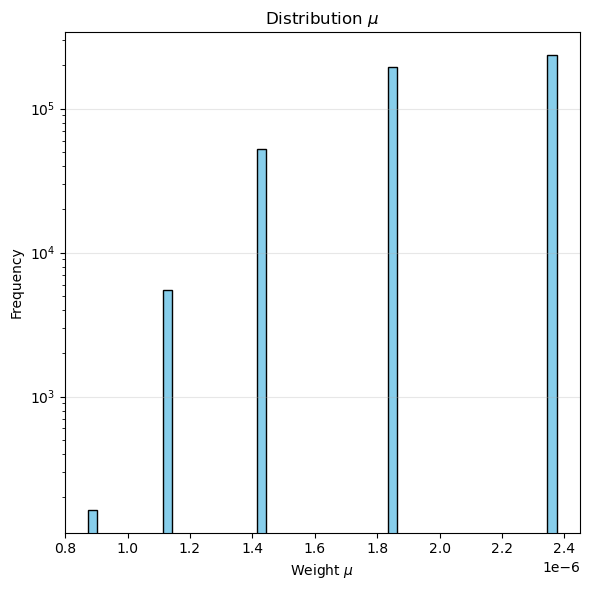

In [105]:
plt.figure(figsize=(6,6))
plt.hist(mu, bins=50, color='skyblue', edgecolor='black', log=True)
plt.title("Distribution $\mu$")
plt.xlabel("Weight $\mu$")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [107]:
dists = compute_distance_nodes(G)
tmp = (0,1,2,36)
print(compute_delta_gromov(dists,tmp))

0.0


Too many quadruples to visualize (10), showing only the first 9.


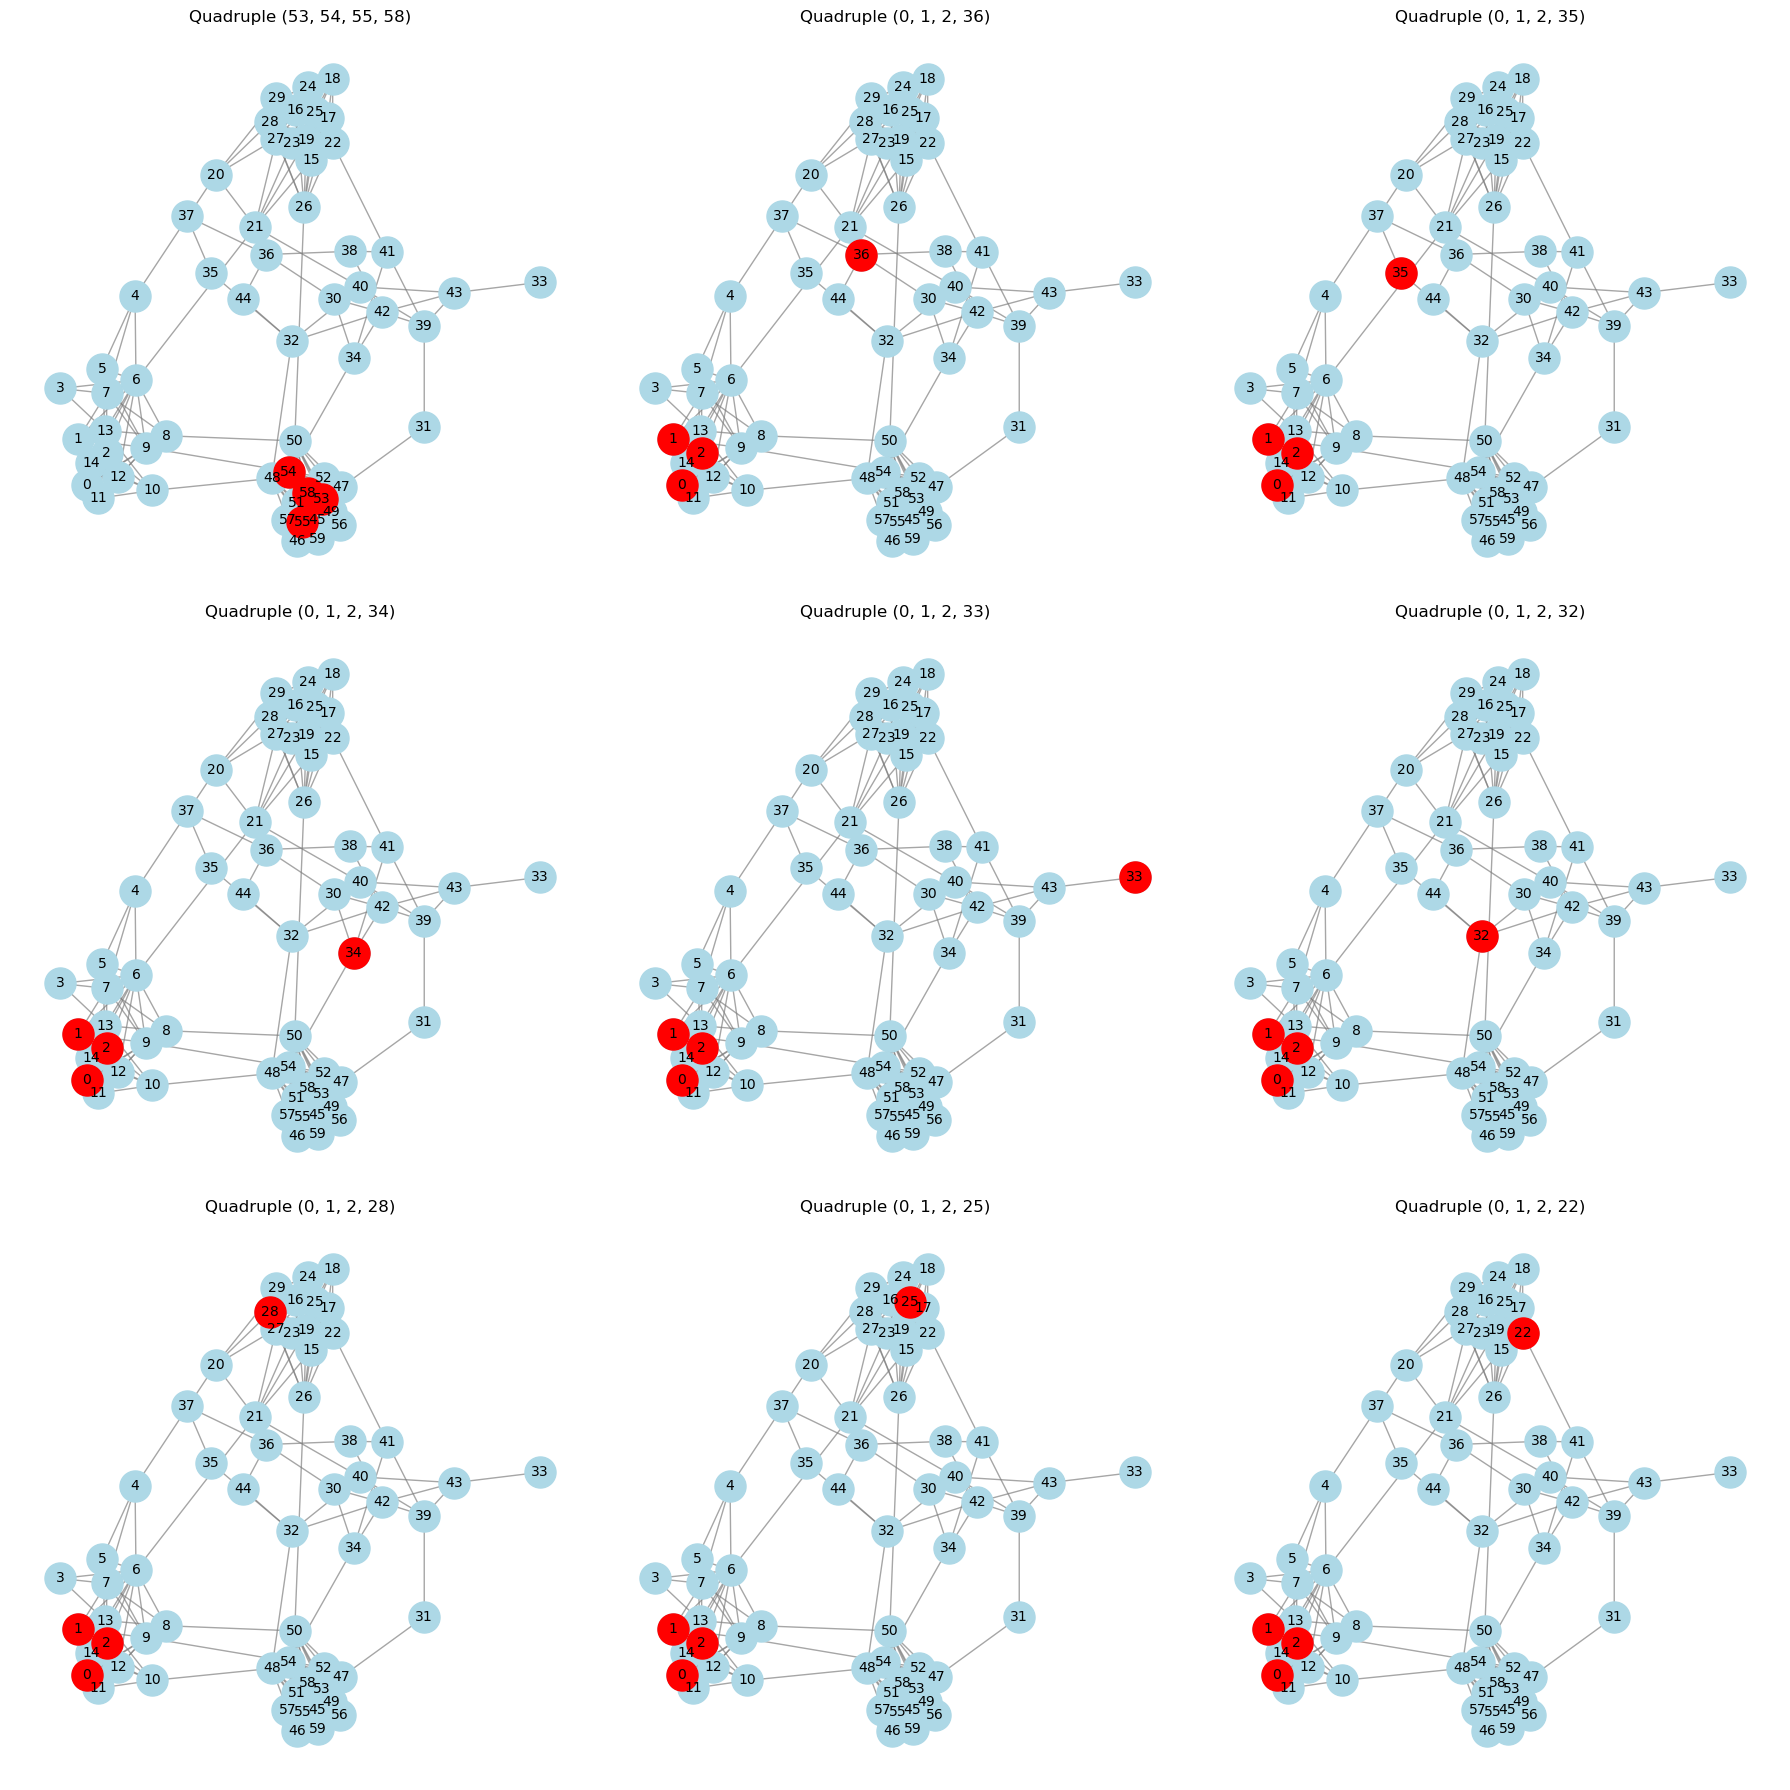

(<Figure size 1800x1800 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (53, 54, 55, 58)'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 36)'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 35)'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 34)'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 33)'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 32)'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 28)'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 25)'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 22)'}>], dtype=object))

In [106]:
draw_quadruples(G,pos,top_quads)

In [110]:
max_delta , mean_delta , delta_distribution = tmp_compute_gromov_hyperbolicity(dists, return_history=False)

In [111]:
delta_distribution

{np.float64(0.5): 194409,
 np.float64(0.0): 235348,
 np.float64(1.0): 52257,
 np.float64(1.5): 5458,
 np.float64(2.0): 163}

In [ ]:
## bisognerebbe calcolare se queste quaterne con gromov = 0 quanto sono vicine, plottare qualcosa con la loro distanza
# ma sono veramente troppe.............

<>:71: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:72: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:88: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:90: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:71: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:72: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:88: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences wil

TOP 10 TUPLE PER PESO MU:
Tupla: (23, 24, 25, 27) | Peso: 0.000047
Tupla: (15, 18, 27, 28) | Peso: 0.000047
Tupla: (15, 18, 25, 28) | Peso: 0.000047
Tupla: (19, 23, 25, 29) | Peso: 0.000047
Tupla: (17, 19, 26, 28) | Peso: 0.000047
Tupla: (15, 18, 23, 28) | Peso: 0.000047
Tupla: (15, 18, 23, 27) | Peso: 0.000047
Tupla: (33, 37, 30, 31) | Peso: 0.000047
Tupla: (23, 24, 25, 29) | Peso: 0.000047
Tupla: (21, 22, 25, 28) | Peso: 0.000047


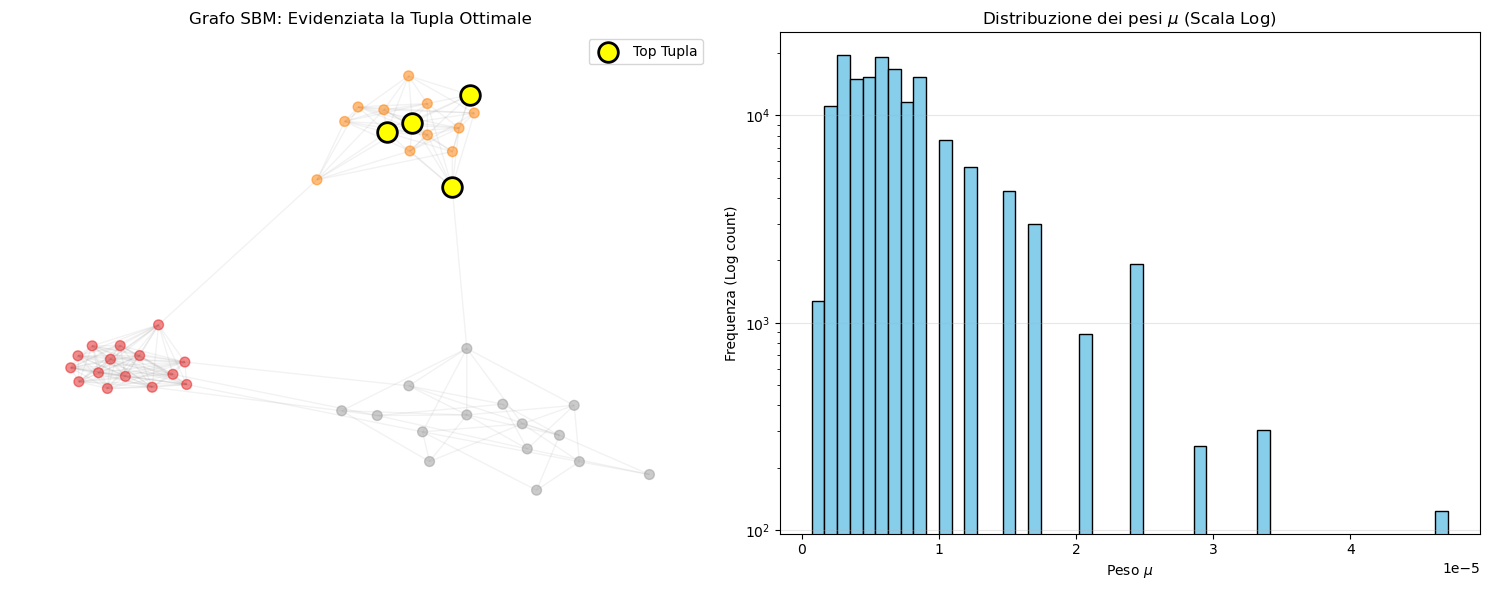

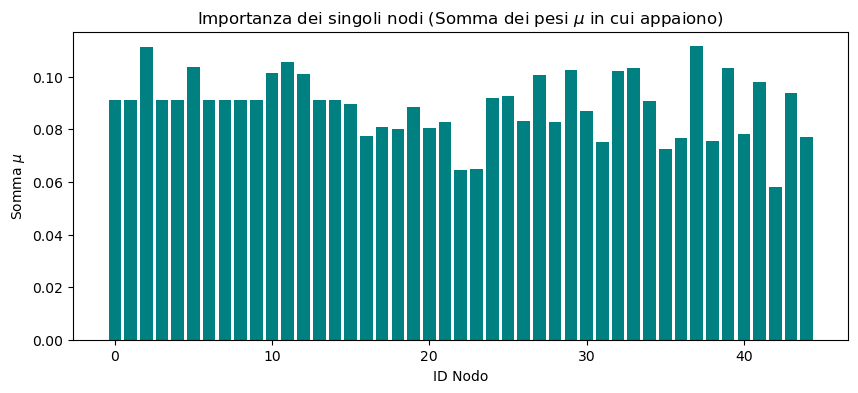

In [86]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.special import softmax

# --- 1. Generazione Grafo e Calcolo (come prima) ---
sizes = [15, 15, 15]
probs = [
    [1.0, 0.01, 0.01],  
    [0.01, 0.6, 0.01],  
    [0.01, 0.01, 0.3]  
]
G = nx.stochastic_block_model(sizes, probs, seed=42)
dists = dict(nx.all_pairs_shortest_path_length(G))

def gromov_point_hyperbolicity(dists, nodes):
    u, v, w, x = nodes
    s = sorted([dists[u][v] + dists[w][x], dists[u][w] + dists[v][x], dists[u][x] + dists[v][w]], reverse=True)
    return (s[0] - s[1]) / 2.0

nodes_list = list(G.nodes())
quads = list(combinations(nodes_list, 4))
scores = []

lambda_reg = 1
gamma = 1

for tup in quads:
    h = gromov_point_hyperbolicity(dists, tup)
    penalty = np.mean([dists[tup[i]][tup[j]] for i in range(4) for j in range(i+1, 4)])
    scores.append(h - (lambda_reg * penalty))

mu_dist = softmax(np.array(scores) / gamma)

# --- 2. Analisi e Stampe ---
top_indices = np.argsort(mu_dist)[-10:][::-1]
print("TOP 10 TUPLE PER PESO MU:")
for i in top_indices:
    print(f"Tupla: {quads[i]} | Peso: {mu_dist[i]:.6f}")

# --- 3. Visualizzazione Grafo ---
plt.figure(figsize=(15, 6))

# Sottografo 1: Il Grafo con le Top Tuple
plt.subplot(1, 2, 1)
pos = nx.spring_layout(G, seed=42)

# Colori per i cluster originali
node_colors = []
for i, size in enumerate(sizes):
    node_colors.extend([i] * size)

# Disegno base
nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')
nx.draw_networkx_nodes(G, pos, node_size=50, node_color=node_colors, cmap=plt.cm.Set1, alpha=0.5)

# Evidenziamo i nodi della top tupla assoluta
top_nodes = quads[top_indices[0]]
nx.draw_networkx_nodes(G, pos, nodelist=top_nodes, node_size=200, 
                       node_color='yellow', edgecolors='black', linewidths=2, label='Top Tupla')

plt.title("Grafo SBM: Evidenziata la Tupla Ottimale")
plt.legend()
plt.axis('off')

# --- 4. Istogramma delle Frequenze (Pesi Mu) ---
plt.subplot(1, 2, 2)
# Usiamo una scala logaritmica se i pesi sono molto concentrati
plt.hist(mu_dist, bins=50, color='skyblue', edgecolor='black', log=True)
plt.title("Distribuzione dei pesi $\mu$ (Scala Log)")
plt.xlabel("Peso $\mu$")
plt.ylabel("Frequenza (Log count)")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# --- 5. Analisi Frequenza Nodi ---
# Vediamo quali nodi compaiono più spesso nelle tuple pesanti
node_importance = np.zeros(len(G.nodes()))
for i, q in enumerate(quads):
    for node in q:
        node_importance[node] += mu_dist[i]

plt.figure(figsize=(10, 4))
plt.bar(range(len(node_importance)), node_importance, color='teal')
plt.title("Importanza dei singoli nodi (Somma dei pesi $\mu$ in cui appaiono)")
plt.xlabel("ID Nodo")
plt.ylabel("Somma $\mu$")
plt.show()